# Weekly HMM Target-Overlap Diagnostic

This notebook tests whether the saved weekly HMM-only probabilities already explain most of the next-week bullish/bearish target. It does not retrain or modify the final weekly HMM-LSTM classifier notebook.

The central comparison is whether the selected LSTM classifiers add information beyond:

- `HMM_Bullish_Prob_Next`, a next-step regime probability.
- `HMM_Positive_Return_Prob_Next`, a next-step probability mapped from training-split state positive-return frequencies and therefore closer to the binary target.

In [7]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)

pd.set_option("display.max_columns", 220)
pd.set_option("display.width", 220)
plt.style.use("default")

PROJECT_ROOT = Path.cwd()
HMM_FEATURE_PATH = PROJECT_ROOT / "outputs" / "weekly_hmm" / "weekly_hmm_regime_features.parquet"
HMM_DIAGNOSTICS_PATH = PROJECT_ROOT / "outputs" / "weekly_hmm" / "weekly_hmm_model_diagnostics.csv"
HMM_STATE_SUMMARY_PATH = PROJECT_ROOT / "outputs" / "weekly_hmm" / "weekly_hmm_state_summary.csv"
FINAL_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "weekly_context_lstm_qqq_final"
LSTM_RESULTS_PATH = FINAL_OUTPUT_DIR / "weekly_context_lstm_qqq_final_results.csv"
LSTM_SELECTED_PATH = FINAL_OUTPUT_DIR / "weekly_context_lstm_qqq_final_selected_models.csv"
LSTM_PREDICTIONS_PATH = FINAL_OUTPUT_DIR / "weekly_context_lstm_qqq_final_predictions.csv"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "weekly_hmm_target_overlap_diagnostic"
PLOTS_DIR = OUTPUT_DIR / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

TICKERS = ["AAPL", "IBM", "MSFT"]
PROBABILITY_MODELS = {
    "hmm_only_bullish_regime_prob": "HMM_Bullish_Prob_Next",
    "hmm_only_positive_return_prob": "HMM_Positive_Return_Prob_Next",
}
THRESHOLD_GRID = np.round(np.arange(0.05, 0.951, 0.01), 2)

## Load Inputs and Check Leakage Metadata

In [8]:
required_hmm_cols = [
    "Ticker",
    "Date",
    "Target_Date",
    "Split",
    "Target_State_Binary",
    "Target_State",
    "HMM_Bullish_Prob_Next",
    "HMM_Positive_Return_Prob_Next",
]

if not HMM_FEATURE_PATH.exists():
    raise FileNotFoundError(f"Missing weekly HMM features: {HMM_FEATURE_PATH}")
if not LSTM_RESULTS_PATH.exists():
    raise FileNotFoundError(f"Missing final LSTM results: {LSTM_RESULTS_PATH}")
if not LSTM_SELECTED_PATH.exists():
    raise FileNotFoundError(f"Missing selected final LSTM models: {LSTM_SELECTED_PATH}")
if not LSTM_PREDICTIONS_PATH.exists():
    raise FileNotFoundError(f"Missing final LSTM predictions: {LSTM_PREDICTIONS_PATH}")

hmm_df = pd.read_parquet(HMM_FEATURE_PATH).copy()
for col in ["Date", "Target_Date"]:
    hmm_df[col] = pd.to_datetime(hmm_df[col])

missing_hmm_cols = [col for col in required_hmm_cols if col not in hmm_df.columns]
if missing_hmm_cols:
    raise ValueError(f"weekly HMM data is missing required columns: {missing_hmm_cols}")

hmm_df = hmm_df[required_hmm_cols].dropna().sort_values(["Ticker", "Date"]).reset_index(drop=True)
for prob_col in PROBABILITY_MODELS.values():
    if not hmm_df[prob_col].between(0, 1).all():
        raise ValueError(f"{prob_col} must be between 0 and 1.")

lstm_results_df = pd.read_csv(LSTM_RESULTS_PATH)
lstm_selected_df = pd.read_csv(LSTM_SELECTED_PATH)
lstm_predictions_df = pd.read_csv(LSTM_PREDICTIONS_PATH, parse_dates=["Date", "Target_Date"])

diagnostics_df = pd.read_csv(HMM_DIAGNOSTICS_PATH) if HMM_DIAGNOSTICS_PATH.exists() else pd.DataFrame()
state_summary_df = pd.read_csv(HMM_STATE_SUMMARY_PATH) if HMM_STATE_SUMMARY_PATH.exists() else pd.DataFrame()

leakage_warnings = []
if diagnostics_df.empty:
    leakage_warnings.append("HMM diagnostics file was not found, so the fit/estimation split could not be verified.")
else:
    for col in ["Scaler_Fitted_On", "HMM_Fitted_On", "Positive_Return_Probability_Estimated_On"]:
        if col not in diagnostics_df.columns:
            leakage_warnings.append(f"HMM diagnostics is missing {col}.")
        elif not diagnostics_df[col].astype(str).str.lower().eq("train").all():
            leakage_warnings.append(
                f"{col} is not marked as train for all tickers: "
                + str(diagnostics_df[["Ticker", col]].to_dict("records"))
            )
if not state_summary_df.empty:
    col = "Positive_Return_Probability_Estimated_On"
    if col in state_summary_df.columns and not state_summary_df[col].astype(str).str.lower().eq("train").all():
        leakage_warnings.append("State positive-return probabilities are not all marked as estimated on train.")

if leakage_warnings:
    for msg in leakage_warnings:
        warnings.warn(msg)
else:
    print("No evidence of validation/test target leakage in HMM metadata: scaler, HMM, and positive-return probabilities are marked as train-only.")

display(hmm_df.groupby(["Ticker", "Split"]).agg(start=("Date", "min"), end=("Date", "max"), rows=("Date", "size")))
display(diagnostics_df if not diagnostics_df.empty else pd.DataFrame({"warning": leakage_warnings}))

No evidence of validation/test target leakage in HMM metadata: scaler, HMM, and positive-return probabilities are marked as train-only.


start        end  rows
Ticker Split                                 
AAPL   test       2023-09-01 2025-12-26   122
       train      2010-07-09 2021-04-30   565
       validation 2021-05-07 2023-08-25   121
IBM    test       2023-09-01 2025-12-26   122
       train      2010-07-09 2021-04-30   565
       validation 2021-05-07 2023-08-25   121
MSFT   test       2023-09-01 2025-12-26   122
       train      2010-07-09 2021-04-30   565
       validation 2021-05-07 2023-08-25   121

,Ticker,Train_Log_Likelihood,Converged,Iterations,Bullish_State,Bearish_State,Training_Mean_Return_Gap,Training_Volatility_Gap,Regime_Diagnostic_Comment,Scaler_Fitted_On,HMM_Fitted_On,Positive_Return_Probability_Estimated_On
0,AAPL,-778.262463,True,135,0,1,0.013139,0.030667,Volatility difference is larger than mean-retu...,train,train,train
1,IBM,-742.978249,True,63,0,1,0.005133,0.038538,Volatility difference is larger than mean-retu...,train,train,train
2,MSFT,-762.080154,True,121,0,1,0.009458,0.043409,Volatility difference is larger than mean-retu...,train,train,train


## HMM-Only Benchmark Helpers

In [9]:
def evaluate_probabilities(y_true: np.ndarray, y_prob: np.ndarray, threshold: float) -> dict:
    y_true = np.asarray(y_true).reshape(-1).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1).astype(float)
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    if len(np.unique(y_true)) == 2:
        auc = roc_auc_score(y_true, y_prob)
    else:
        auc = np.nan
    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "cohen_kappa": cohen_kappa_score(y_true, y_pred),
        "roc_auc": auc,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "share_predicted_bullish": float(y_pred.mean()),
        "share_actual_bullish": float(y_true.mean()),
        "probability_mean": float(y_prob.mean()),
        "probability_std": float(y_prob.std(ddof=0)),
        "probability_min": float(y_prob.min()),
        "probability_max": float(y_prob.max()),
    }


def select_validation_threshold(y_true: np.ndarray, y_prob: np.ndarray) -> tuple[float, pd.DataFrame]:
    rows = []
    for threshold in THRESHOLD_GRID:
        row = evaluate_probabilities(y_true, y_prob, threshold)
        rows.append(row)
    threshold_df = pd.DataFrame(rows)
    selected = (
        threshold_df.sort_values(["balanced_accuracy", "f1", "accuracy"], ascending=[False, False, False])
        .iloc[0]["threshold"]
    )
    return float(selected), threshold_df


benchmark_rows = []
prediction_frames = []
threshold_frames = []

for ticker in TICKERS:
    ticker_df = hmm_df.loc[hmm_df["Ticker"].eq(ticker)].copy()
    val_df = ticker_df.loc[ticker_df["Split"].eq("validation")].copy()
    test_df = ticker_df.loc[ticker_df["Split"].eq("test")].copy()
    if val_df.empty or test_df.empty:
        raise ValueError(f"{ticker} needs non-empty validation and test splits.")

    for model_name, prob_col in PROBABILITY_MODELS.items():
        selected_threshold, threshold_df = select_validation_threshold(
            val_df["Target_State_Binary"].to_numpy(),
            val_df[prob_col].to_numpy(),
        )
        threshold_df.insert(0, "Ticker", ticker)
        threshold_df.insert(1, "model_name", model_name)
        threshold_df.insert(2, "probability_column", prob_col)
        threshold_frames.append(threshold_df)

        for threshold_type, threshold in [
            ("fixed_threshold_0_50", 0.50),
            ("validation_selected_threshold", selected_threshold),
        ]:
            for split, split_df in [("validation", val_df), ("test", test_df)]:
                metrics = evaluate_probabilities(
                    split_df["Target_State_Binary"].to_numpy(),
                    split_df[prob_col].to_numpy(),
                    threshold,
                )
                benchmark_rows.append(
                    {
                        "ticker": ticker,
                        "model_name": model_name,
                        "probability_column": prob_col,
                        "split": split,
                        "threshold_type": threshold_type,
                        **metrics,
                    }
                )
                pred_df = split_df[["Ticker", "Date", "Target_Date", "Split", "Target_State_Binary", "Target_State"]].copy()
                pred_df["model_name"] = model_name
                pred_df["probability_column"] = prob_col
                pred_df["threshold_type"] = threshold_type
                pred_df["decision_threshold"] = threshold
                pred_df["predicted_bullish_probability"] = split_df[prob_col].astype(float).to_numpy()
                pred_df["predicted_state_binary"] = (pred_df["predicted_bullish_probability"] >= threshold).astype(int)
                pred_df["predicted_state"] = np.where(pred_df["predicted_state_binary"].eq(1), "Bullish", "Bearish")
                prediction_frames.append(pred_df)

hmm_only_results_df = pd.DataFrame(benchmark_rows)
hmm_only_predictions_df = pd.concat(prediction_frames, ignore_index=True)
hmm_threshold_search_df = pd.concat(threshold_frames, ignore_index=True)

hmm_only_results_df.to_csv(OUTPUT_DIR / "weekly_hmm_only_benchmark_results.csv", index=False)
hmm_only_predictions_df.to_csv(OUTPUT_DIR / "weekly_hmm_only_benchmark_predictions.csv", index=False)
hmm_threshold_search_df.to_csv(OUTPUT_DIR / "weekly_hmm_only_threshold_search.csv", index=False)

display(hmm_only_results_df.sort_values(["ticker", "model_name", "threshold_type", "split"]))

,ticker,model_name,probability_column,split,threshold_type,threshold,accuracy,balanced_accuracy,f1,cohen_kappa,roc_auc,tn,fp,fn,tp,share_predicted_bullish,share_actual_bullish,probability_mean,probability_std,probability_min,probability_max
1,AAPL,hmm_only_bullish_regime_prob,HMM_Bullish_Prob_Next,test,fixed_threshold_0_50,0.50,0.500000,0.495929,0.541353,-0.008128,0.437449,25,30,31,36,0.540984,0.549180,0.522440,0.205054,0.105820,0.824666
0,AAPL,hmm_only_bullish_regime_prob,HMM_Bullish_Prob_Next,validation,fixed_threshold_0_50,0.50,0.619835,0.615152,0.656716,0.231003,0.625895,31,24,22,44,0.561983,0.545455,0.521815,0.243438,0.105849,0.828381
3,AAPL,hmm_only_bullish_regime_prob,HMM_Bullish_Prob_Next,test,validation_selected_threshold,0.65,0.434426,0.450882,0.355140,-0.094099,0.437449,34,21,48,19,0.327869,0.549180,0.522440,0.205054,0.105820,0.824666
2,AAPL,hmm_only_bullish_regime_prob,HMM_Bullish_Prob_Next,validation,validation_selected_threshold,0.65,0.628099,0.639394,0.601770,0.270987,0.625895,42,13,32,34,0.388430,0.545455,0.521815,0.243438,0.105849,0.828381
5,AAPL,hmm_only_positive_return_prob,HMM_Positive_Return_Prob_Next,test,fixed_threshold_0_50,0.50,0.524590,0.482497,0.677778,-0.037841,0.437449,3,52,6,61,0.926230,0.549180,0.571322,0.045681,0.478510,0.638651
4,AAPL,hmm_only_positive_return_prob,HMM_Positive_Return_Prob_Next,validation,fixed_threshold_0_50,0.50,0.545455,0.512121,0.678363,0.025765,0.625895,8,47,8,58,0.867769,0.545455,0.571183,0.054232,0.478516,0.639478
7,AAPL,hmm_only_positive_return_prob,HMM_Positive_Return_Prob_Next,test,validation_selected_threshold,0.60,0.434426,0.450882,0.355140,-0.094099,0.437449,34,21,48,19,0.327869,0.549180,0.571322,0.045681,0.478510,0.638651
6,AAPL,hmm_only_positive_return_prob,HMM_Positive_Return_Prob_Next,validation,validation_selected_threshold,0.60,0.628099,0.639394,0.601770,0.270987,0.625895,42,13,32,34,0.388430,0.545455,0.571183,0.054232,0.478516,0.639478
9,IBM,hmm_only_bullish_regime_prob,HMM_Bullish_Prob_Next,test,fixed_threshold_0_50,0.50,0.590164,0.537725,0.698795,0.080772,0.539414,14,34,16,58,0.754098,0.606557,0.647369,0.209657,0.216870,0.870415
8,IBM,hmm_only_bullish_regime_prob,HMM_Bullish_Prob_Next,validation,fixed_threshold_0_50,0.50,0.504132,0.485302,0.615385,-0.030372,0.480769,13,43,17,48,0.752066,0.537190,0.650922,0.200137,0.216870,0.862759


## LSTM Comparison Table

In [10]:
TARGET_FEATURE_CONFIGS = [
    "technical_only",
    "hmm_informed",
    "vol_context_compact_hmm",
    "vol_market_context_qqq_hmm",
]

def lstm_selected_to_comparison(selected_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in selected_df.loc[selected_df["feature_config"].isin(TARGET_FEATURE_CONFIGS)].iterrows():
        for threshold_type, prefix in [
            ("fixed_threshold_0_50", "fixed_threshold_0_50_test"),
            ("validation_selected_threshold", "validation_selected_threshold_test"),
        ]:
            rows.append(
                {
                    "ticker": row["ticker"],
                    "model_name": f"{row['feature_config']}_lstm",
                    "feature_config": row["feature_config"],
                    "architecture_config": row["architecture_config"],
                    "lookback": row["lookback"],
                    "threshold_type": threshold_type,
                    "test_accuracy": row[f"{prefix}_accuracy"],
                    "test_balanced_accuracy": row[f"{prefix}_balanced_accuracy"],
                    "test_f1": row[f"{prefix}_f1"],
                    "test_kappa": row[f"{prefix}_kappa"],
                    "test_roc_auc": row[f"{prefix}_roc_auc"],
                    "test_probability_std": row[f"{prefix}_probability_std"],
                }
            )
    return pd.DataFrame(rows)


def hmm_to_comparison(hmm_results: pd.DataFrame) -> pd.DataFrame:
    test_df = hmm_results.loc[hmm_results["split"].eq("test")].copy()
    return pd.DataFrame(
        {
            "ticker": test_df["ticker"],
            "model_name": test_df["model_name"],
            "feature_config": np.nan,
            "architecture_config": np.nan,
            "lookback": np.nan,
            "threshold_type": test_df["threshold_type"],
            "test_accuracy": test_df["accuracy"],
            "test_balanced_accuracy": test_df["balanced_accuracy"],
            "test_f1": test_df["f1"],
            "test_kappa": test_df["cohen_kappa"],
            "test_roc_auc": test_df["roc_auc"],
            "test_probability_std": test_df["probability_std"],
        }
    )

lstm_comparison_df = lstm_selected_to_comparison(lstm_selected_df)
hmm_comparison_df = hmm_to_comparison(hmm_only_results_df)
comparison_df = pd.concat([lstm_comparison_df, hmm_comparison_df], ignore_index=True)

comparison_order = [
    "technical_only_lstm",
    "hmm_informed_lstm",
    "vol_context_compact_hmm_lstm",
    "vol_market_context_qqq_hmm_lstm",
    "hmm_only_bullish_regime_prob",
    "hmm_only_positive_return_prob",
]
comparison_df["model_name"] = pd.Categorical(comparison_df["model_name"], categories=comparison_order, ordered=True)
comparison_df = comparison_df.sort_values(["ticker", "threshold_type", "model_name"]).reset_index(drop=True)
comparison_df["model_name"] = comparison_df["model_name"].astype(str)
comparison_df.to_csv(OUTPUT_DIR / "weekly_hmm_vs_lstm_comparison.csv", index=False)

display(comparison_df)

,ticker,model_name,feature_config,architecture_config,lookback,threshold_type,test_accuracy,test_balanced_accuracy,test_f1,test_kappa,test_roc_auc,test_probability_std
0,AAPL,technical_only_lstm,technical_only,stacked,8.0,fixed_threshold_0_50,0.516393,0.499457,0.604027,-0.001113,0.505563,0.021897
1,AAPL,hmm_informed_lstm,hmm_informed,medium,4.0,fixed_threshold_0_50,0.475410,0.478426,0.483871,-0.042457,0.496608,0.024479
2,AAPL,vol_context_compact_hmm_lstm,vol_context_compact_hmm,stacked,8.0,fixed_threshold_0_50,0.524590,0.532972,0.508475,0.064269,0.523745,0.148642
3,AAPL,vol_market_context_qqq_hmm_lstm,vol_market_context_qqq_hmm,stacked,8.0,fixed_threshold_0_50,0.516393,0.517368,0.535433,0.034344,0.523745,0.227815
4,AAPL,hmm_only_bullish_regime_prob,NaN,NaN,NaN,fixed_threshold_0_50,0.500000,0.495929,0.541353,-0.008128,0.437449,0.205054
5,AAPL,hmm_only_positive_return_prob,NaN,NaN,NaN,fixed_threshold_0_50,0.524590,0.482497,0.677778,-0.037841,0.437449,0.045681
6,AAPL,technical_only_lstm,technical_only,stacked,8.0,validation_selected_threshold,0.524590,0.526459,0.539683,0.052237,0.505563,0.021897
7,AAPL,hmm_informed_lstm,hmm_informed,medium,4.0,validation_selected_threshold,0.475410,0.478426,0.483871,-0.042457,0.496608,0.024479
8,AAPL,vol_context_compact_hmm_lstm,vol_context_compact_hmm,stacked,8.0,validation_selected_threshold,0.540984,0.554410,0.500000,0.105056,0.523745,0.148642
9,AAPL,vol_market_context_qqq_hmm_lstm,vol_market_context_qqq_hmm,stacked,8.0,validation_selected_threshold,0.500000,0.504071,0.504065,0.007998,0.523745,0.227815


## Delta Tables

In [11]:
DELTA_METRICS = [
    "test_accuracy",
    "test_balanced_accuracy",
    "test_f1",
    "test_kappa",
    "test_roc_auc",
    "test_probability_std",
]


def make_delta_table(challenger: str, baseline: str, label: str) -> pd.DataFrame:
    key_cols = ["ticker", "threshold_type"]
    left = comparison_df.loc[comparison_df["model_name"].eq(challenger), key_cols + DELTA_METRICS]
    right = comparison_df.loc[comparison_df["model_name"].eq(baseline), key_cols + DELTA_METRICS]
    merged = left.merge(right, on=key_cols, suffixes=("_challenger", "_baseline"), validate="one_to_one")
    merged.insert(2, "comparison", label)
    merged.insert(3, "challenger", challenger)
    merged.insert(4, "baseline", baseline)
    for metric in DELTA_METRICS:
        merged[f"delta_{metric}"] = merged[f"{metric}_challenger"] - merged[f"{metric}_baseline"]
    return merged[key_cols + ["comparison", "challenger", "baseline"] + [f"delta_{m}" for m in DELTA_METRICS]]

delta_tables = [
    make_delta_table("hmm_informed_lstm", "hmm_only_positive_return_prob", "hmm_informed_lstm_minus_hmm_only_positive_return"),
    make_delta_table("hmm_informed_lstm", "hmm_only_bullish_regime_prob", "hmm_informed_lstm_minus_hmm_only_bullish_regime"),
    make_delta_table("hmm_informed_lstm", "technical_only_lstm", "hmm_informed_lstm_minus_technical_only_lstm"),
    make_delta_table("vol_market_context_qqq_hmm_lstm", "hmm_only_positive_return_prob", "vol_market_context_qqq_hmm_lstm_minus_hmm_only_positive_return"),
    make_delta_table("vol_market_context_qqq_hmm_lstm", "hmm_only_bullish_regime_prob", "vol_market_context_qqq_hmm_lstm_minus_hmm_only_bullish_regime"),
]
deltas_df = pd.concat(delta_tables, ignore_index=True)
deltas_df.to_csv(OUTPUT_DIR / "weekly_hmm_vs_lstm_deltas.csv", index=False)
display(deltas_df.sort_values(["threshold_type", "comparison", "ticker"]))

,ticker,threshold_type,comparison,challenger,baseline,delta_test_accuracy,delta_test_balanced_accuracy,delta_test_f1,delta_test_kappa,delta_test_roc_auc,delta_test_probability_std
6,AAPL,fixed_threshold_0_50,hmm_informed_lstm_minus_hmm_only_bullish_regime,hmm_informed_lstm,hmm_only_bullish_regime_prob,-0.024590,-0.017503,-0.057482,-0.034329,0.059159,-0.180575
8,IBM,fixed_threshold_0_50,hmm_informed_lstm_minus_hmm_only_bullish_regime,hmm_informed_lstm,hmm_only_bullish_regime_prob,-0.106557,-0.018300,-0.246621,-0.046107,-0.008727,-0.186815
10,MSFT,fixed_threshold_0_50,hmm_informed_lstm_minus_hmm_only_bullish_regime,hmm_informed_lstm,hmm_only_bullish_regime_prob,0.032787,0.077112,-0.058505,0.158551,0.117309,-0.080208
0,AAPL,fixed_threshold_0_50,hmm_informed_lstm_minus_hmm_only_positive_return,hmm_informed_lstm,hmm_only_positive_return_prob,-0.049180,-0.004071,-0.193907,-0.004616,0.059159,-0.021202
2,IBM,fixed_threshold_0_50,hmm_informed_lstm_minus_hmm_only_positive_return,hmm_informed_lstm,hmm_only_positive_return_prob,-0.155738,-0.033221,-0.311267,-0.087638,-0.008727,0.013199
4,MSFT,fixed_threshold_0_50,hmm_informed_lstm_minus_hmm_only_positive_return,hmm_informed_lstm,hmm_only_positive_return_prob,0.024590,0.074241,-0.072080,0.152531,0.117309,0.044172
12,AAPL,fixed_threshold_0_50,hmm_informed_lstm_minus_technical_only_lstm,hmm_informed_lstm,technical_only_lstm,-0.040984,-0.021031,-0.120156,-0.041344,-0.008955,0.002582
14,IBM,fixed_threshold_0_50,hmm_informed_lstm_minus_technical_only_lstm,hmm_informed_lstm,technical_only_lstm,-0.024590,0.063908,-0.181972,0.129162,0.119932,0.006431
16,MSFT,fixed_threshold_0_50,hmm_informed_lstm_minus_technical_only_lstm,hmm_informed_lstm,technical_only_lstm,0.057377,0.055100,0.058263,0.111263,0.072190,0.030565
24,AAPL,fixed_threshold_0_50,vol_market_context_qqq_hmm_lstm_minus_hmm_only...,vol_market_context_qqq_hmm_lstm,hmm_only_bullish_regime_prob,0.016393,0.021438,-0.005920,0.042472,0.086296,0.022761


## Probability Bins and Plots

In [12]:
def save_plot(filename: str) -> Path:
    path = PLOTS_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.close()
    return path

plot_paths = []

bins_df = hmm_df.loc[hmm_df["Split"].isin(["validation", "test"])].copy()
bins_df["probability_bin"] = pd.cut(
    bins_df["HMM_Positive_Return_Prob_Next"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True,
)
probability_bins_df = (
    bins_df.groupby(["Ticker", "Split", "probability_bin"], observed=False)
    .agg(
        rows=("Target_State_Binary", "size"),
        actual_bullish_share=("Target_State_Binary", "mean"),
        probability_mean=("HMM_Positive_Return_Prob_Next", "mean"),
    )
    .reset_index()
)
probability_bins_df["probability_bin"] = probability_bins_df["probability_bin"].astype(str)
probability_bins_df.to_csv(OUTPUT_DIR / "weekly_hmm_probability_bins.csv", index=False)
display(probability_bins_df)

plot_df = comparison_df.loc[comparison_df["threshold_type"].eq("validation_selected_threshold")].copy()
for metric, ylabel, filename in [
    ("test_roc_auc", "Test ROC-AUC", "test_roc_auc_comparison_by_ticker.png"),
    ("test_balanced_accuracy", "Test balanced accuracy", "test_balanced_accuracy_comparison_by_ticker.png"),
]:
    fig, axes = plt.subplots(1, len(TICKERS), figsize=(5.6 * len(TICKERS), 4.5), sharey=True)
    if len(TICKERS) == 1:
        axes = [axes]
    for ax, ticker in zip(axes, TICKERS):
        df_t = plot_df.loc[plot_df["ticker"].eq(ticker)].dropna(subset=[metric]).copy()
        ax.barh(df_t["model_name"], df_t[metric], color="#4C78A8")
        ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
        ax.set_title(ticker)
        ax.set_xlabel(ylabel)
    fig.suptitle(f"{ylabel} comparison, validation-selected thresholds")
    plot_paths.append(save_plot(filename))

dist_df = hmm_df.loc[hmm_df["Split"].eq("test")].copy()
dist_df["Actual Target"] = np.where(dist_df["Target_State_Binary"].eq(1), "Bullish", "Bearish")
fig, axes = plt.subplots(len(TICKERS), 2, figsize=(11, 3.2 * len(TICKERS)), sharex=True)
if len(TICKERS) == 1:
    axes = np.asarray([axes])
for r, ticker in enumerate(TICKERS):
    for c, (title, prob_col) in enumerate([
        ("HMM bullish regime probability", "HMM_Bullish_Prob_Next"),
        ("HMM positive-return probability", "HMM_Positive_Return_Prob_Next"),
    ]):
        ax = axes[r, c]
        for target, color in [("Bearish", "#E45756"), ("Bullish", "#54A24B")]:
            vals = dist_df.loc[dist_df["Ticker"].eq(ticker) & dist_df["Actual Target"].eq(target), prob_col]
            ax.hist(vals, bins=12, alpha=0.58, label=target, color=color)
        ax.set_title(f"{ticker}: {title}")
        ax.set_xlabel("Probability")
        ax.set_ylabel("Count")
        ax.legend()
plot_paths.append(save_plot("hmm_probability_distribution_by_actual_target_class.png"))

test_bins_df = probability_bins_df.loc[probability_bins_df["Split"].eq("test")].copy()
fig, axes = plt.subplots(1, len(TICKERS), figsize=(5.2 * len(TICKERS), 4.2), sharey=True)
if len(TICKERS) == 1:
    axes = [axes]
for ax, ticker in zip(axes, TICKERS):
    df_t = test_bins_df.loc[test_bins_df["Ticker"].eq(ticker) & test_bins_df["rows"].gt(0)].copy()
    ax.plot(df_t["probability_mean"], df_t["actual_bullish_share"], marker="o", color="#4C78A8")
    ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
    ax.set_title(ticker)
    ax.set_xlabel("Mean HMM positive-return probability")
    ax.set_ylabel("Actual bullish share")
fig.suptitle("Calibration-style test bin plot")
plot_paths.append(save_plot("hmm_positive_return_probability_calibration_bins.png"))

cm_df = hmm_only_results_df.loc[hmm_only_results_df["split"].eq("test")].copy()
fig, axes = plt.subplots(len(TICKERS), 4, figsize=(13, 3.2 * len(TICKERS)))
if len(TICKERS) == 1:
    axes = np.asarray([axes])
for r, ticker in enumerate(TICKERS):
    df_t = cm_df.loc[cm_df["ticker"].eq(ticker)].sort_values(["model_name", "threshold_type"])
    for c, (_, row) in enumerate(df_t.iterrows()):
        ax = axes[r, c]
        matrix = np.array([[row["tn"], row["fp"]], [row["fn"], row["tp"]]], dtype=int)
        ax.imshow(matrix, cmap="Blues")
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(matrix[i, j]), ha="center", va="center", color="black")
        ax.set_xticks([0, 1], ["Pred Bear", "Pred Bull"])
        ax.set_yticks([0, 1], ["Actual Bear", "Actual Bull"])
        ax.set_title(f"{ticker}\n{row['model_name']}\n{row['threshold_type']}")
fig.suptitle("HMM-only test confusion matrices")
plot_paths.append(save_plot("hmm_only_confusion_matrices.png"))

for path in plot_paths:
    print(path)

,Ticker,Split,probability_bin,rows,actual_bullish_share,probability_mean
0,AAPL,test,"(-0.001, 0.1]",0,NaN,NaN
1,AAPL,test,"(0.1, 0.2]",0,NaN,NaN
2,AAPL,test,"(0.2, 0.3]",0,NaN,NaN
3,AAPL,test,"(0.3, 0.4]",0,NaN,NaN
4,AAPL,test,"(0.4, 0.5]",9,0.666667,0.486367
5,AAPL,test,"(0.5, 0.6]",73,0.575342,0.553512
6,AAPL,test,"(0.6, 0.7]",40,0.475000,0.622940
7,AAPL,test,"(0.7, 0.8]",0,NaN,NaN
8,AAPL,test,"(0.8, 0.9]",0,NaN,NaN
9,AAPL,test,"(0.9, 1.0]",0,NaN,NaN


d:\BA_year_3\honour project\outputs\weekly_hmm_target_overlap_diagnostic\plots\test_roc_auc_comparison_by_ticker.png
d:\BA_year_3\honour project\outputs\weekly_hmm_target_overlap_diagnostic\plots\test_balanced_accuracy_comparison_by_ticker.png
d:\BA_year_3\honour project\outputs\weekly_hmm_target_overlap_diagnostic\plots\hmm_probability_distribution_by_actual_target_class.png
d:\BA_year_3\honour project\outputs\weekly_hmm_target_overlap_diagnostic\plots\hmm_positive_return_probability_calibration_bins.png
d:\BA_year_3\honour project\outputs\weekly_hmm_target_overlap_diagnostic\plots\hmm_only_confusion_matrices.png


## Inline Seaborn Plots

These plots are shown directly in the notebook output only. They are not saved to disk.

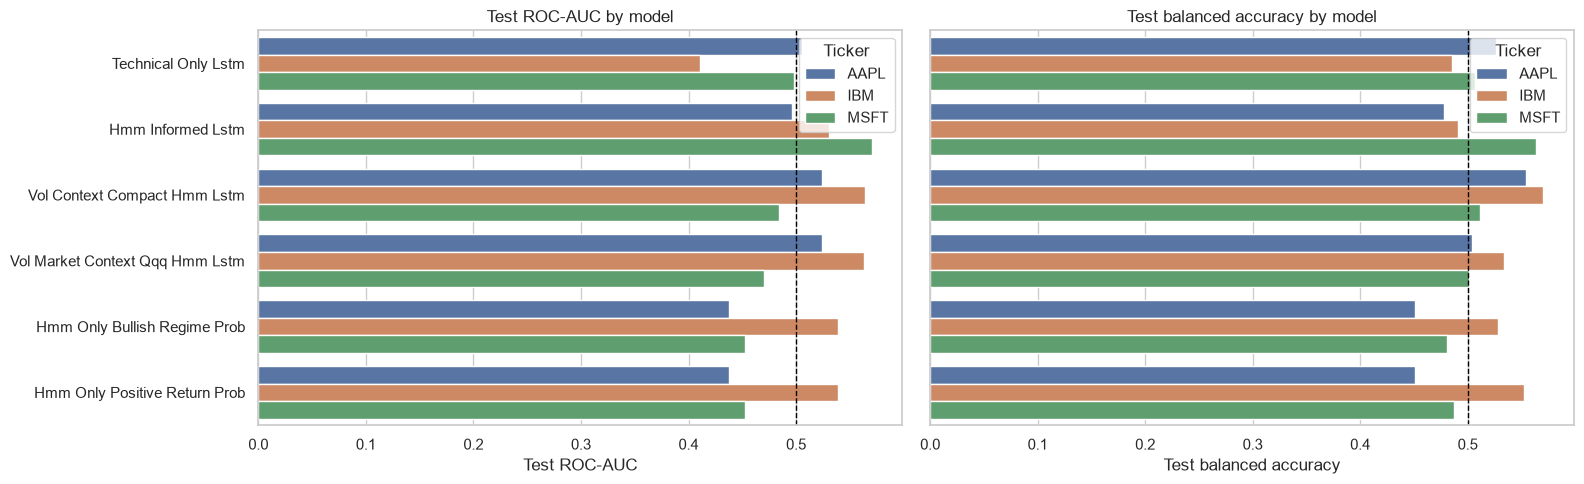

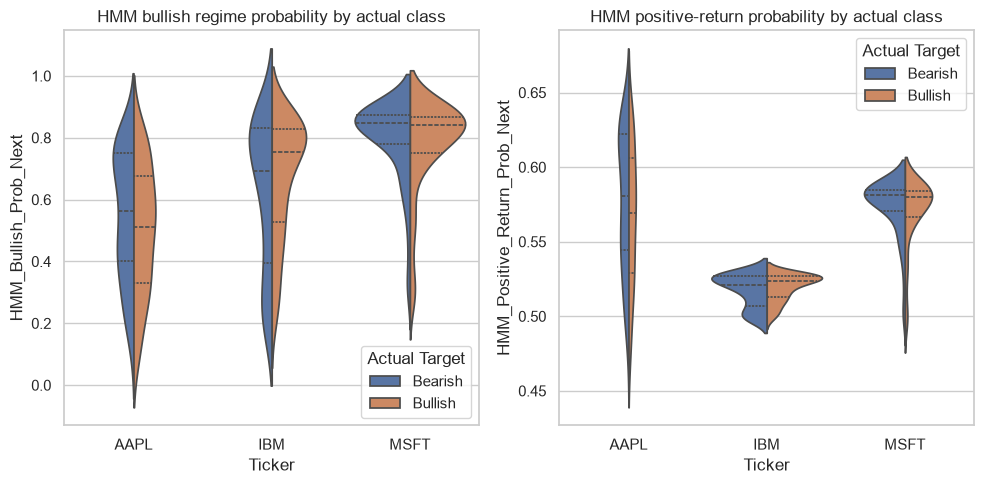

In [14]:
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

inline_plot_df = comparison_df.loc[
    comparison_df["threshold_type"].eq("validation_selected_threshold")
].copy()
inline_plot_df["model_label"] = inline_plot_df["model_name"].str.replace("_", " ").str.title()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

sns.barplot(
    data=inline_plot_df,
    x="test_roc_auc",
    y="model_label",
    hue="ticker",
    ax=axes[0],
)
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Test ROC-AUC by model")
axes[0].set_xlabel("Test ROC-AUC")
axes[0].set_ylabel("")

sns.barplot(
    data=inline_plot_df,
    x="test_balanced_accuracy",
    y="model_label",
    hue="ticker",
    ax=axes[1],
)
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Test balanced accuracy by model")
axes[1].set_xlabel("Test balanced accuracy")
axes[1].set_ylabel("")

for ax in axes:
    ax.legend(title="Ticker")

plt.tight_layout()
plt.show()

hmm_test_plot_df = hmm_df.loc[hmm_df["Split"].eq("test")].copy()
hmm_test_plot_df["Actual Target"] = np.where(
    hmm_test_plot_df["Target_State_Binary"].eq(1), "Bullish", "Bearish"
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=False)

sns.violinplot(
    data=hmm_test_plot_df,
    x="Ticker",
    y="HMM_Bullish_Prob_Next",
    hue="Actual Target",
    split=True,
    inner="quartile",
    ax=axes[0],
)
axes[0].set_title("HMM bullish regime probability by actual class")
axes[0].set_ylabel("HMM_Bullish_Prob_Next")

sns.violinplot(
    data=hmm_test_plot_df,
    x="Ticker",
    y="HMM_Positive_Return_Prob_Next",
    hue="Actual Target",
    split=True,
    inner="quartile",
    ax=axes[1],
)
axes[1].set_title("HMM positive-return probability by actual class")
axes[1].set_ylabel("HMM_Positive_Return_Prob_Next")

plt.tight_layout()
plt.show()

## Interpretation

The diagnostic supports the concern that the current HMM signal is target-adjacent: it is already closely aligned with the next-week positive/negative return target. Therefore, the HMM-informed LSTM does not have a consistent advantage over the HMM-only benchmark.

Moreover, for the HMM bullish-regime probability is not strong discriminating between actual positive and negatiive next-week returns. Regarding MSFT, the HMM often gives high bullish-regime probability even when the actual target is bearish. That suggests the HMM regime is more like a persistent market-condition signal, not a precise next-week direction predictor.

